In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.shape

(1025, 14)

In [8]:
df.size

14350

In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
cols=df.columns.tolist()

In [12]:
import math
n=len(cols)
rows=math.ceil(n/2)

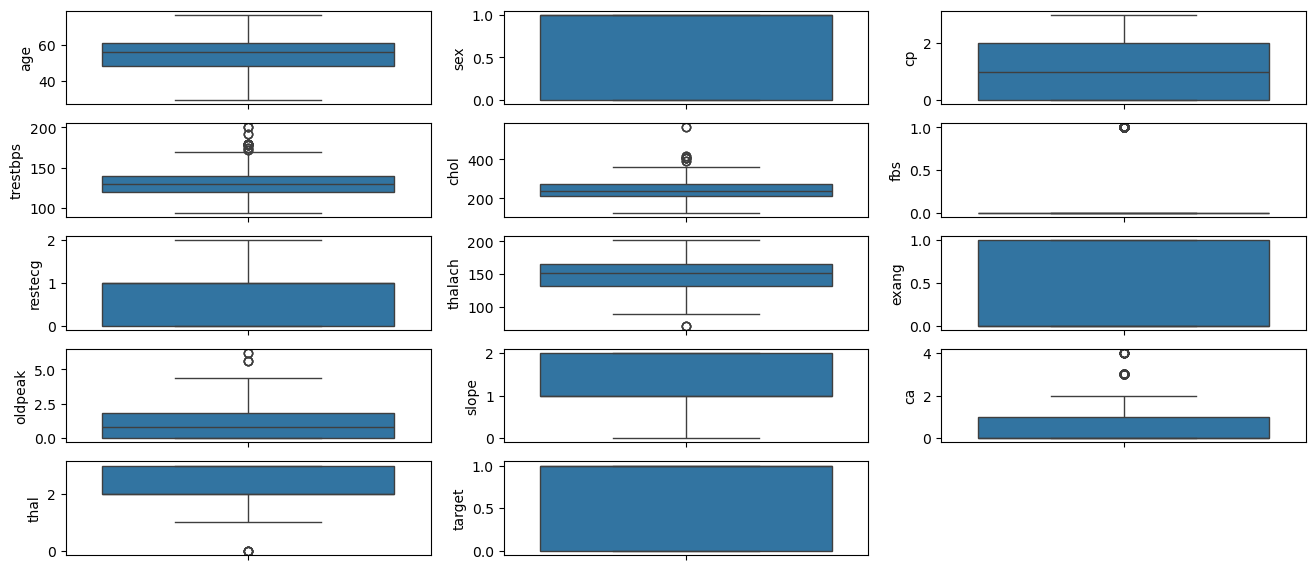

In [15]:
plt.figure(figsize=(16,10))
for i in range(len(cols)):
    plt.subplot(rows,3,i+1)
    sns.boxplot(df[cols[i]])
    plt.xticks(rotation=45,ha="right")

In [16]:
from scipy.stats.mstats import winsorize

In [17]:
w_cols=["trestbps","chol","fbs","ca","thal","oldpeak","thalach"]

In [23]:
for w_cols1 in w_cols:
    df[w_cols1]=winsorize(df[w_cols1],limits=(0.20,0.20))

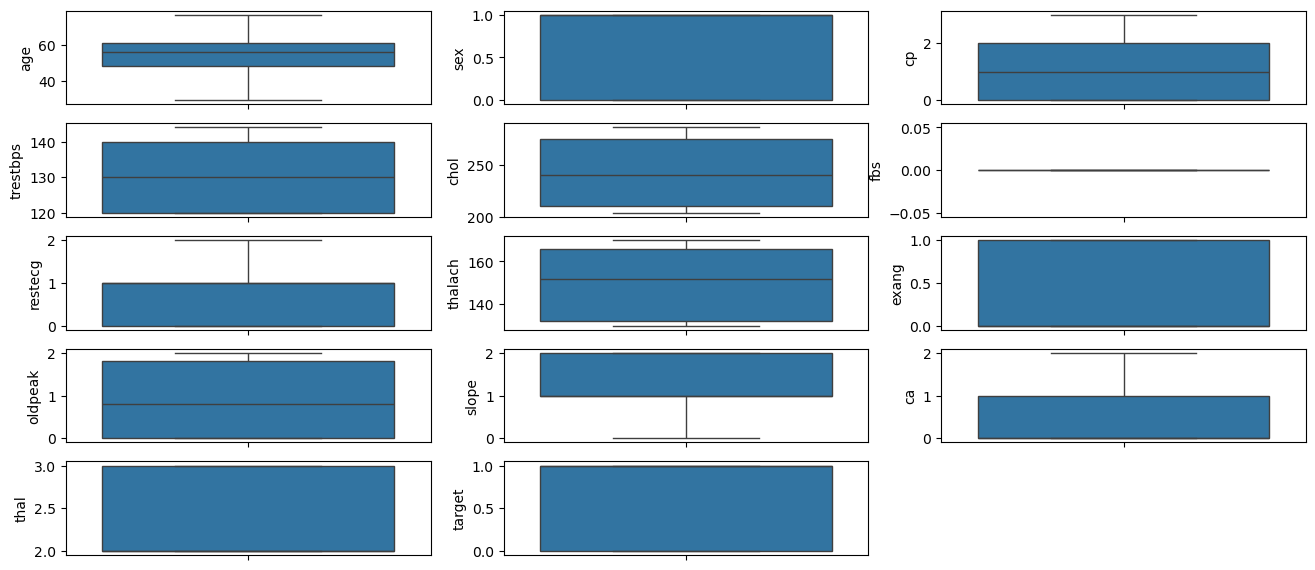

In [24]:
plt.figure(figsize=(16,10))
for i in range(len(cols)):
    plt.subplot(rows,3,i+1)
    sns.boxplot(df[cols[i]])
    plt.xticks(rotation=45,ha="right")

In [27]:
from sklearn.preprocessing import StandardScaler

In [29]:
s_cols=["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal"]
ss=StandardScaler()
df[s_cols]=ss.fit_transform(df[s_cols])

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score

In [32]:
X=df.drop("target",axis=1)
y=df["target"]

In [33]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [66]:
dc=DecisionTreeClassifier()

In [67]:
dc.fit(X_train,y_train)

DecisionTreeClassifier()

In [68]:
y_pred=dc.predict(X_test)

In [69]:
print("Accuracy_score:",accuracy_score(y_test,y_pred))

Accuracy_score: 0.9853658536585366


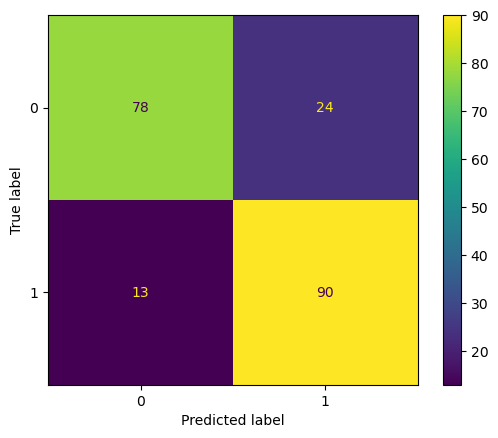

In [208]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

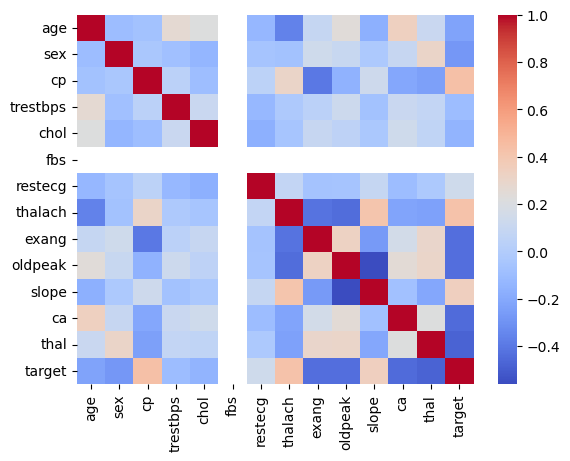

In [213]:
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score

In [86]:
X=df.drop("target",axis=1)
y=df["target"]

In [87]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [100]:
svm=SVC(kernel="rbf",gamma="scale",C=1000)

In [101]:
svm.fit(X_train,y_train)

SVC(C=1000)

In [102]:
y_pred=svm.predict(X_test)

In [103]:
print("Accuracy_score:",accuracy_score(y_test,y_pred))

Accuracy_score: 0.9853658536585366


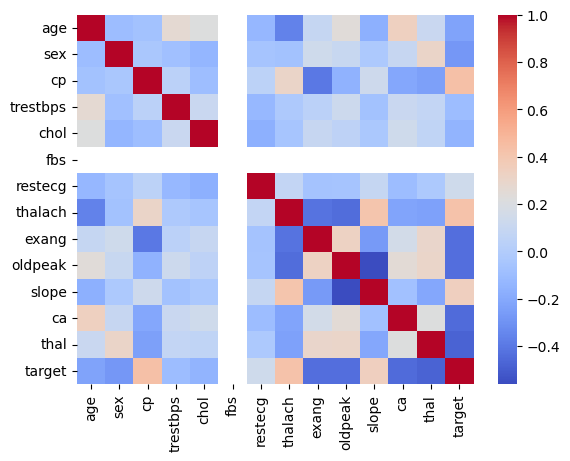

In [214]:
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

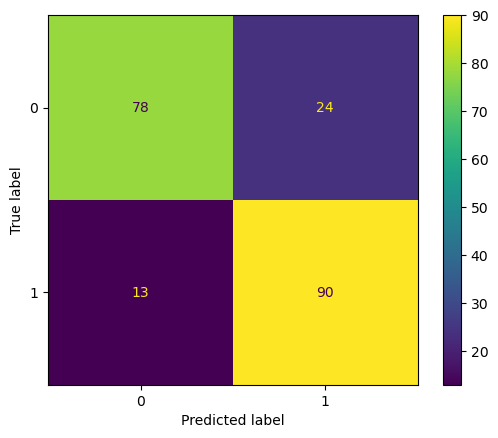

In [215]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score

In [115]:
X=df.drop("target",axis=1)
y=df["target"]

In [116]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [143]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    criterion="entropy",
    random_state=42
)



In [144]:
rf.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', max_depth=15, min_samples_leaf=2,
                       min_samples_split=5, n_estimators=300, random_state=42)

In [145]:
y_pred=rf.predict(X_test)

In [146]:
print("Accuracy_score:",accuracy_score(y_test,y_pred))

Accuracy_score: 0.9707317073170731


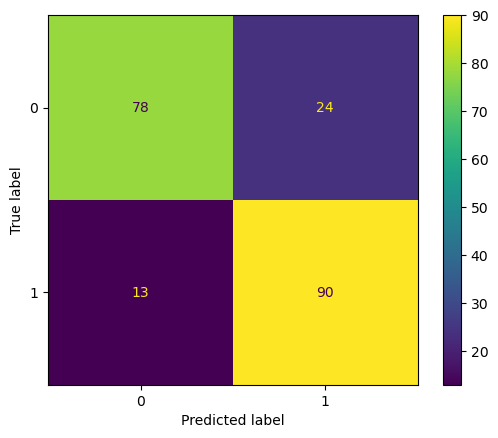

In [216]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

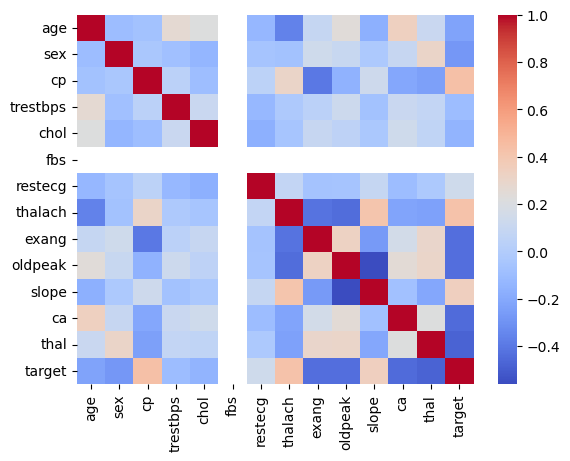

In [217]:
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

In [150]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score

In [154]:
X=df.drop("target",axis=1)
y=df["target"]

In [155]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [184]:
knn=KNeighborsClassifier(n_neighbors=7,weights="uniform",metric="minkowski")

In [185]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=7)

In [186]:
y_pred=knn.predict(X_test)

In [187]:
print("Accuracy_score:",accuracy_score(y_test,y_pred))

Accuracy_score: 0.8292682926829268


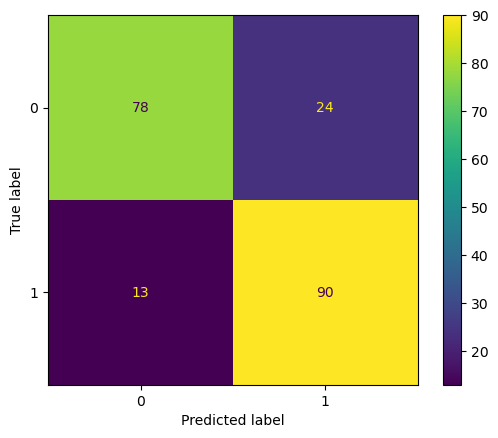

In [218]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

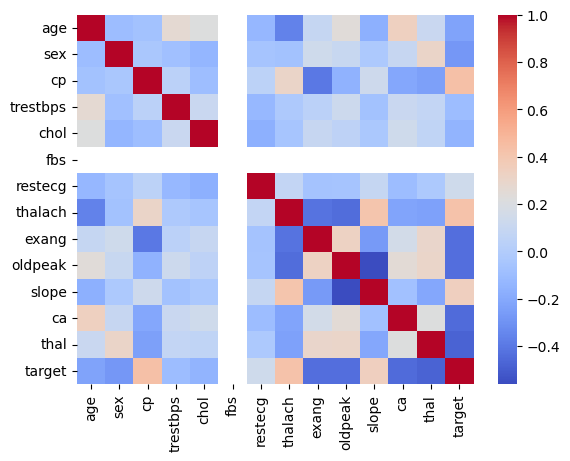

In [219]:
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

In [199]:

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score

In [200]:
X=df.drop("target",axis=1)
y=df["target"]

In [201]:
gnb=GaussianNB()

In [202]:
gnb.fit(X_train,y_train)

GaussianNB()

In [203]:
y_pred=gnb.predict(X_test)

In [204]:
print("Accuracy_score:",accuracy_score(y_test,y_pred))

Accuracy_score: 0.8195121951219512


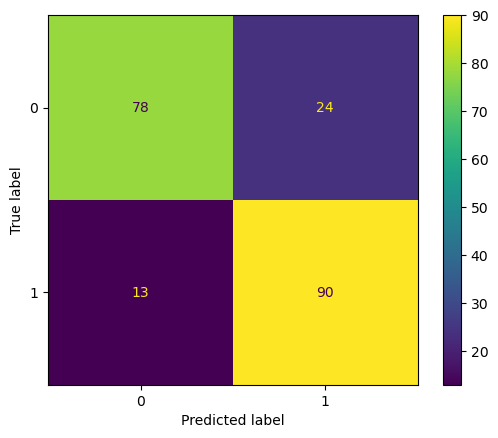

In [220]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

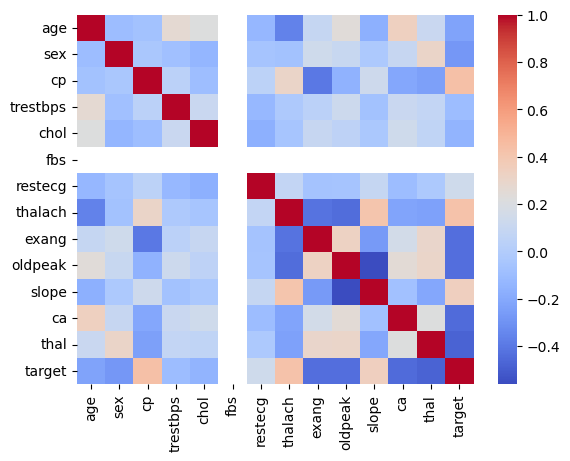

In [221]:
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

In [224]:
import pandas as pd

results = {
    "Decision Tree":0.9853658536585366,
    "Random Forest": 0.9707317073170731,
    "SVM": 0.9853658536585366,
    "KNN": 0.8292682926829268,
    "Naive Bayes": 0.8195121951219512
}

result_df = pd.DataFrame(results.items(),
                         columns=["Model", "Accuracy"])

result_df = result_df.sort_values("Accuracy",
                                  ascending=False)

print(result_df)

           Model  Accuracy
0  Decision Tree  0.985366
2            SVM  0.985366
1  Random Forest  0.970732
3            KNN  0.829268
4    Naive Bayes  0.819512


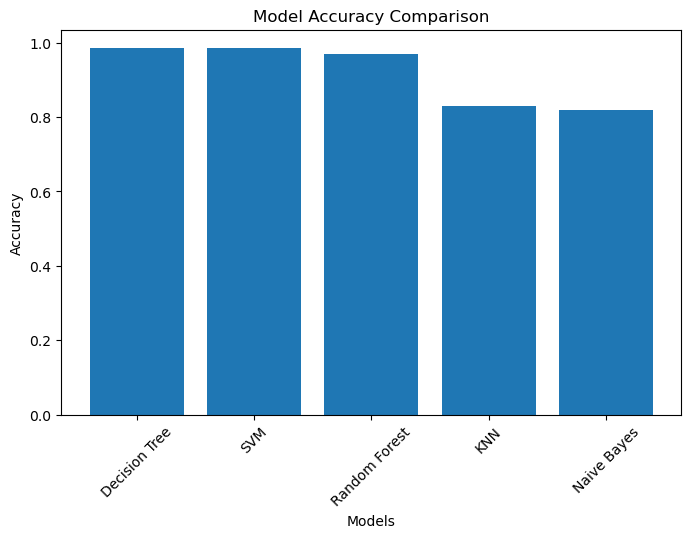

In [223]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(result_df["Model"],
        result_df["Accuracy"])

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=45)

plt.show()